Dataset shape: (96453, 3)
       Humidity  Wind Speed (km/h)  Temperature (C)
count  96453.00           96453.00         96453.00
mean       0.73              10.81            11.93
std        0.20               6.91             9.55
min        0.00               0.00           -21.82
25%        0.60               5.83             4.69
50%        0.78               9.97            12.00
75%        0.89              14.14            18.84
max        1.00              63.85            39.91


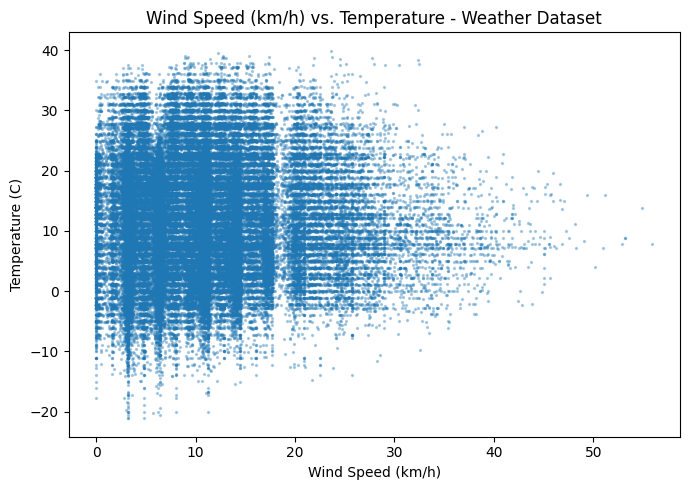

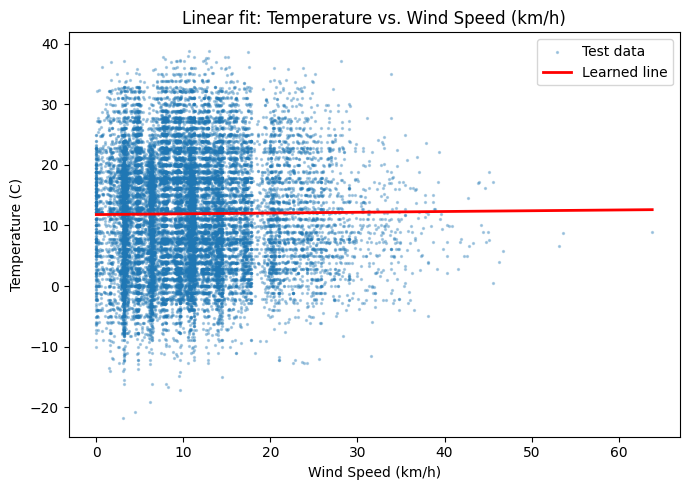


=== Wind Speed (km/h) ===
Rows used (train/test)       : 77162 / 19291
Learned model                : Temperature = 0.0127 * Wind Speed (km/h) + 11.80
Correlation with temperature : +0.009
Mean Absolute Error (test)   : 7.90 degrees C
(Predict-the-mean baseline   : 7.89 degrees C)


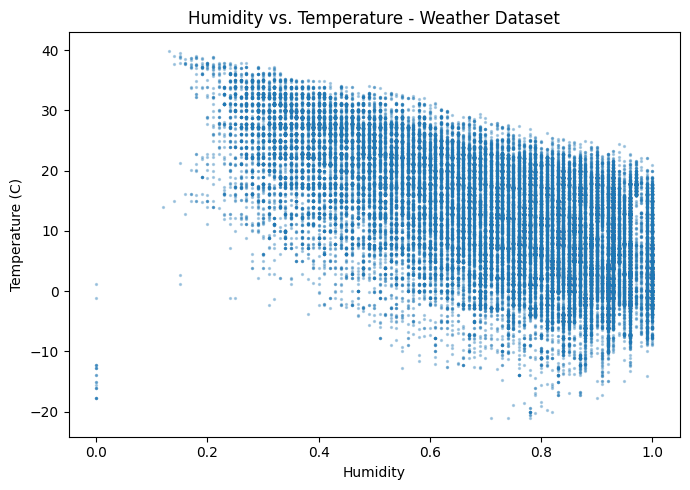

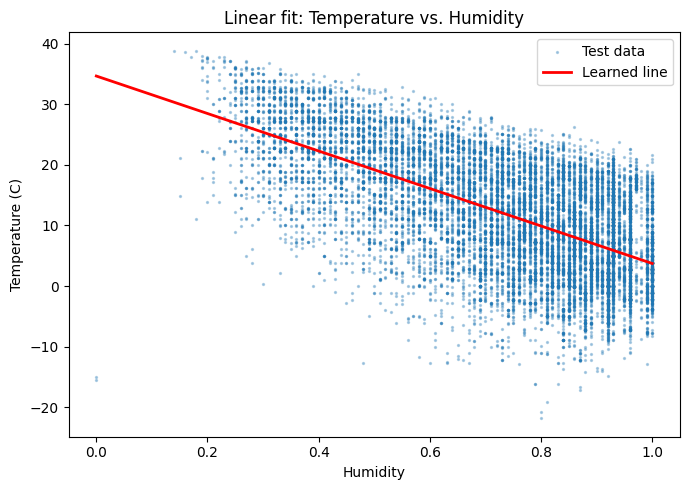


=== Humidity ===
Rows used (train/test)       : 77162 / 19291
Learned model                : Temperature = -30.9303 * Humidity + 34.66
Correlation with temperature : -0.632
Mean Absolute Error (test)   : 6.01 degrees C
(Predict-the-mean baseline   : 7.89 degrees C)

=== Comparison ===
Wind Speed (km/h)     : MAE = 7.90 C (r = +0.009)
Humidity              : MAE = 6.01 C (r = -0.632)
Lower error: Humidity.
Reason: a linear model can only exploit a straight-line relationship; the feature whose correlation with temperature is stronger (larger |r|) leaves less unexplained variation, so its predictions are closer to the true temperatures.


In [1]:
import glob
import os
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
 
# ----------------------------- Configuration -----------------------------
NEW_FEATURE = "Wind Speed (km/h)"      # try also: "Pressure (millibars)"
BASELINE_FEATURE = "Humidity"          # feature used in the lab demo
TARGET = "Temperature (C)"
TRAIN_FRACTION = 0.8
SEED = 42
 
 
# ------------------------------ Data loading -----------------------------
def locate_weather_csv() -> str:
    """Find weatherHistory.csv on Kaggle, locally, or download via kagglehub."""
    search_patterns = [
        "/kaggle/input/**/weatherHistory.csv",
        "./weatherHistory.csv",
        "./**/weatherHistory.csv",
    ]
    for pattern in search_patterns:
        hits = glob.glob(pattern, recursive=True)
        if hits:
            return hits[0]
 
    try:
        import kagglehub  # works on Colab / local machines
 
        folder = kagglehub.dataset_download("muthuj7/weather-dataset")
        return os.path.join(folder, "weatherHistory.csv")
    except Exception as err:
        raise FileNotFoundError(
            "weatherHistory.csv not found. On Kaggle use '+ Add Input' -> "
            "'muthuj7/weather-dataset'. Elsewhere run: pip install kagglehub"
        ) from err
 
 
def load_data() -> pd.DataFrame:
    df = pd.read_csv(locate_weather_csv())
    needed = [BASELINE_FEATURE, NEW_FEATURE, TARGET]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns {missing}. Available: {list(df.columns)}")
    df = df[needed].apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)
    return df
 
 
# ------------------------------ Model (from Lab 1) ------------------------
def train_linear_regression(x_values: np.ndarray, y_values: np.ndarray):
    """Least-squares fit of y = m*x + b."""
    mean_x, mean_y = x_values.mean(), y_values.mean()
    denominator = np.sum((x_values - mean_x) ** 2)
    if denominator == 0:
        raise ValueError("Feature has zero variance; cannot fit a line.")
    m = np.sum((x_values - mean_x) * (y_values - mean_y)) / denominator
    b = mean_y - m * mean_x
    return m, b
 
 
def mean_absolute_error(predictions: np.ndarray, truth: np.ndarray) -> float:
    return float(np.mean(np.abs(predictions - truth)))
 
 
# ------------------------------ Plot helpers ------------------------------
def scatter_plot(x, y, feature, filename):
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, s=2, alpha=0.3)
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.title(f"{feature} vs. Temperature - Weather Dataset")
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
 
 
def fit_plot(x_test, y_test, m, b, feature, filename):
    plt.figure(figsize=(7, 5))
    plt.scatter(x_test, y_test, s=2, alpha=0.3, label="Test data")
    grid = np.linspace(x_test.min(), x_test.max(), 100)
    plt.plot(grid, m * grid + b, color="red", linewidth=2, label="Learned line")
    plt.xlabel(feature)
    plt.ylabel(TARGET)
    plt.title(f"Linear fit: Temperature vs. {feature}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.show()
 
 
# ------------------------------ Experiment --------------------------------
def run_experiment(df, feature, train_idx, test_idx, plot_prefix):
    """Fit and evaluate one feature; returns (m, b, mae, correlation)."""
    X = df[feature].to_numpy(dtype=float)
    y = df[TARGET].to_numpy(dtype=float)
 
    # Pressure contains invalid 0-millibar readings -> drop them for that feature only.
    valid = (X != 0) if "pressure" in feature.lower() else np.ones(len(X), dtype=bool)
    tr = train_idx[valid[train_idx]]
    te = test_idx[valid[test_idx]]
 
    X_train, y_train, X_test, y_test = X[tr], y[tr], X[te], y[te]
 
    # Step 1: visualise BEFORE modelling (training data only)
    scatter_plot(X_train, y_train, feature, f"{plot_prefix}_scatter.png")
 
    # Step 2: train
    m, b = train_linear_regression(X_train, y_train)
 
    # Step 3: evaluate on held-out test data
    predictions = m * X_test + b
    mae = mean_absolute_error(predictions, y_test)
    baseline_mae = mean_absolute_error(np.full_like(y_test, y_train.mean()), y_test)
    corr = float(np.corrcoef(X_train, y_train)[0, 1])
 
    fit_plot(X_test, y_test, m, b, feature, f"{plot_prefix}_fit.png")
 
    print(f"\n=== {feature} ===")
    print(f"Rows used (train/test)       : {len(tr)} / {len(te)}")
    print(f"Learned model                : Temperature = {m:.4f} * {feature} + {b:.2f}")
    print(f"Correlation with temperature : {corr:+.3f}")
    print(f"Mean Absolute Error (test)   : {mae:.2f} degrees C")
    print(f"(Predict-the-mean baseline   : {baseline_mae:.2f} degrees C)")
    return m, b, mae, corr
 
 
def main():
    df = load_data()
    print("Dataset shape:", df.shape)
    print(df.describe().round(2))
 
    # One shared 80/20 split so both features are judged on the same rows
    rng = np.random.default_rng(SEED)
    indices = rng.permutation(len(df))
    split = int(TRAIN_FRACTION * len(df))
    train_idx, test_idx = indices[:split], indices[split:]
 
    _, _, mae_new, corr_new = run_experiment(df, NEW_FEATURE, train_idx, test_idx, "task1_new_feature")
    _, _, mae_base, corr_base = run_experiment(df, BASELINE_FEATURE, train_idx, test_idx, "task1_humidity")
 
    # Comparison / written observation
    print("\n=== Comparison ===")
    print(f"{NEW_FEATURE:<22}: MAE = {mae_new:.2f} C (r = {corr_new:+.3f})")
    print(f"{BASELINE_FEATURE:<22}: MAE = {mae_base:.2f} C (r = {corr_base:+.3f})")
    winner = BASELINE_FEATURE if mae_base < mae_new else NEW_FEATURE
    print(f"Lower error: {winner}.")
    print(
        "Reason: a linear model can only exploit a straight-line relationship; the feature "
        "whose correlation with temperature is stronger (larger |r|) leaves less unexplained "
        "variation, so its predictions are closer to the true temperatures."
    )
 
 
if __name__ == "__main__":
    main()